# E03 Matrix Sensing Ablations

This experiment keeps the MatrixSensing objective from E01 but changes the problem assumptions one at a time.

The objective remains

$$
f(X) = \frac{1}{2m}\sum_{i=1}^{m}(\langle A_i, X\rangle-y_i)^2.
$$

E01 answers how optimizers scale with dimension under the baseline setting. E03 answers which modeling choices make the same problem harder: measurement distribution, spectrum shape, condition number, and observation noise.

## Setup

In [1]:
import os
import pathlib
import sys
import time
for name in ["OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"]:
    os.environ.setdefault(name, "1")

import joblib
import IPython.display
import matplotlib.pyplot as plt
import pandas as pd
import torch

PROJECT = pathlib.Path.cwd().resolve()
if not (PROJECT / "problems").exists():
    PROJECT = PROJECT.parent.resolve()
sys.path.insert(0, str(PROJECT))

import optimizers
import plotting
import problems.MatrixConstruction
import problems.MatrixFactorization
import problems.MatrixSensing
import util

torch.set_default_dtype(torch.float64)
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

print(f"project = {PROJECT}")
print(f"torch   = {torch.__version__}")
print(f"joblib  = {joblib.__version__}")


project = /Users/tianyangliu/Desktop/muonexperiment
torch   = 2.9.1
joblib  = 1.5.2


## Parameters And Grid Preview

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE_NAME = "float64"
ALGOS = ["Muon", "Muon-Exact", "Shampoo", "Adam", "SGD"]
SEEDS = list(range(10))
SMOKE_TEST = False
SMOKE_TEST_MAX_STEPS = 10
FULL_ITERS = 2000

BASE_SPEC = dict(
    d=60,
    rank=5,
    lr=0.01,
    init_scale=0.01,
    iters=SMOKE_TEST_MAX_STEPS if SMOKE_TEST else FULL_ITERS,
    early_stop=True,
    early_stop_min_steps=20,
    early_stop_patience=20,
    early_stop_min_delta=1e-3,
    device_type=DEVICE.type,
    dtype_name=DTYPE_NAME,
)
SCENARIOS = [
    dict(scenario="baseline-normal", dist="normal", spectrum="hard-cutoff", kappa=1.0, noise=0.0),
    dict(scenario="rademacher-meas", dist="rademacher", spectrum="hard-cutoff", kappa=1.0, noise=0.0),
    dict(scenario="sphere-meas", dist="sphere", spectrum="hard-cutoff", kappa=1.0, noise=0.0),
    dict(scenario="polynomial-spectrum", dist="normal", spectrum="polynomial-decay", kappa=1.0, noise=0.0),
    dict(scenario="exponential-spectrum", dist="normal", spectrum="exponential-decay", kappa=1.0, noise=0.0),
    dict(scenario="kappa-100", dist="normal", spectrum="hard-cutoff", kappa=100.0, noise=0.0),
    dict(scenario="noise-0.01", dist="normal", spectrum="hard-cutoff", kappa=1.0, noise=0.01),
]
SCENARIO_ORDER = [scenario["scenario"] for scenario in SCENARIOS]
NUM_WORKERS = min(8, os.cpu_count() or 1)
JOBLIB_BACKEND = "loky"

runs = pd.DataFrame([
    {**BASE_SPEC, **scenario, "algo": algo, "seed": seed}
    for scenario in SCENARIOS
    for algo in ALGOS
    for seed in SEEDS
])
runs["problem"] = "MatrixSensing"
runs.insert(0, "run_id", range(len(runs)))
runs["scenario"] = pd.Categorical(runs["scenario"], categories=SCENARIO_ORDER, ordered=True)
preview_cols = [
    "run_id", "scenario", "problem", "algo", "d", "rank", "seed", "lr", "iters",
    "early_stop", "early_stop_min_steps", "early_stop_patience", "early_stop_min_delta",
    "noise", "dist", "spectrum", "kappa", "init_scale", "device_type", "dtype_name",
]
runs = runs[preview_cols]
runs["scenario"] = runs["scenario"].astype(str)

print(f"device={DEVICE}, workers={NUM_WORKERS}, backend={JOBLIB_BACKEND}")
print(f"smoke_test={SMOKE_TEST}, smoke_test_max_steps={SMOKE_TEST_MAX_STEPS}")
print(f"scenarios={len(SCENARIOS)}, runs={len(runs)}, max_iters={BASE_SPEC['iters']}, max_total_steps={len(runs) * BASE_SPEC['iters']}")
print(
    "early_stop=patience on absolute loss improvement "
    f"(min_steps={BASE_SPEC['early_stop_min_steps']}, "
    f"patience={BASE_SPEC['early_stop_patience']}, "
    f"min_delta={BASE_SPEC['early_stop_min_delta']})"
)
IPython.display.display(pd.DataFrame(SCENARIOS))
IPython.display.display(runs)


device=cpu, workers=8, backend=loky
smoke_test=False, smoke_test_max_steps=10
scenarios=7, runs=350, max_iters=2000, max_total_steps=700000
early_stop=patience on absolute loss improvement (min_steps=20, patience=20, min_delta=0.001)


,scenario,dist,spectrum,kappa,noise
0,baseline-normal,normal,hard-cutoff,1.0,0.00
1,rademacher-meas,rademacher,hard-cutoff,1.0,0.00
2,sphere-meas,sphere,hard-cutoff,1.0,0.00
3,polynomial-spectrum,normal,polynomial-decay,1.0,0.00
4,exponential-spectrum,normal,exponential-decay,1.0,0.00
5,kappa-100,normal,hard-cutoff,100.0,0.00
6,noise-0.01,normal,hard-cutoff,1.0,0.01


,run_id,scenario,problem,algo,d,rank,seed,lr,iters,early_stop,early_stop_min_steps,early_stop_patience,early_stop_min_delta,noise,dist,spectrum,kappa,init_scale,device_type,dtype_name
0,0,baseline-normal,MatrixSensing,Muon,60,5,0,0.01,2000,True,20,20,0.001,0.00,normal,hard-cutoff,1.0,0.01,cpu,float64
1,1,baseline-normal,MatrixSensing,Muon,60,5,1,0.01,2000,True,20,20,0.001,0.00,normal,hard-cutoff,1.0,0.01,cpu,float64
2,2,baseline-normal,MatrixSensing,Muon,60,5,2,0.01,2000,True,20,20,0.001,0.00,normal,hard-cutoff,1.0,0.01,cpu,float64
3,3,baseline-normal,MatrixSensing,Muon,60,5,3,0.01,2000,True,20,20,0.001,0.00,normal,hard-cutoff,1.0,0.01,cpu,float64
4,4,baseline-normal,MatrixSensing,Muon,60,5,4,0.01,2000,True,20,20,0.001,0.00,normal,hard-cutoff,1.0,0.01,cpu,float64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345,345,noise-0.01,MatrixSensing,SGD,60,5,5,0.01,2000,True,20,20,0.001,0.01,normal,hard-cutoff,1.0,0.01,cpu,float64
346,346,noise-0.01,MatrixSensing,SGD,60,5,6,0.01,2000,True,20,20,0.001,0.01,normal,hard-cutoff,1.0,0.01,cpu,float64
347,347,noise-0.01,MatrixSensing,SGD,60,5,7,0.01,2000,True,20,20,0.001,0.01,normal,hard-cutoff,1.0,0.01,cpu,float64
348,348,noise-0.01,MatrixSensing,SGD,60,5,8,0.01,2000,True,20,20,0.001,0.01,normal,hard-cutoff,1.0,0.01,cpu,float64


## Experiment Pseudocode

```text
for each scenario in SCENARIOS:
    for each algorithm and seed:
        build X_star and measurement tensors according to the scenario
        initialize X
        choose optimizer
        for step in range(iters):
            loss = 0.5 * mean((<A_i, X> - y_i)^2)
            backprop through X
            optimizer.step()
            record loss, grad_norm, elapsed time
            stop if patience-based early stopping fires
concat all per-run tables back into runs
```

This experiment is intentionally longer than E01 because it multiplies the baseline optimizer grid by several problem scenarios.

## Worker Definition

In [3]:
def dtype_from_name(dtype_name):
    dtype = getattr(torch, dtype_name)
    if not isinstance(dtype, torch.dtype):
        raise ValueError(f"unknown torch dtype: {dtype_name}")
    return dtype


def configure_torch(dtype):
    torch.set_default_dtype(dtype)
    torch.set_num_threads(1)
    try:
        torch.set_num_interop_threads(1)
    except RuntimeError:
        pass


def make_optimizer(algo, params, lr, rank):
    if algo == "Muon" and hasattr(torch.optim, "Muon"):
        return torch.optim.Muon(params, lr=lr, weight_decay=0.0, momentum=0.9, nesterov=False, ns_steps=5)
    if algo == "Muon":
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="newton_schulz", ns_steps=5)
    if algo in {"Muon-Exact", "MuonExact"}:
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="exact")
    if algo == "Shampoo":
        return optimizers.Shampoo(params, lr=lr, beta2=0.9, epsilon=1e-8)
    if algo == "Adam":
        return torch.optim.Adam(params, lr=lr)
    if algo == "SGD":
        return torch.optim.SGD(params, lr=lr, momentum=0.9)
    raise ValueError(f"unknown algo: {algo}")


def single_run(run):
    run = dict(run)
    d = int(run["d"])
    rank = int(run["rank"])
    seed = int(run["seed"])
    iters = int(run["iters"])
    early_stop = bool(run["early_stop"])
    early_stop_min_steps = int(run["early_stop_min_steps"])
    early_stop_patience = int(run["early_stop_patience"])
    early_stop_min_delta = float(run["early_stop_min_delta"])
    device = torch.device(run["device_type"])
    dtype = dtype_from_name(run["dtype_name"])
    configure_torch(dtype)

    def initialize_problem(run):
        return problems.MatrixSensing.make_matrix_sensing_problem(
            d,
            rank,
            noise=float(run["noise"]),
            dist=run["dist"],
            spectrum=run["spectrum"],
            kappa=float(run["kappa"]),
            seed=seed,
            device=device,
            dtype=dtype,
        )

    def optimization(problem, run):
        x = torch.nn.Parameter(problems.MatrixConstruction.randn((d, d), seed + 3000, device, dtype) * float(run["init_scale"]))
        state = {
            "problem": problem,
            "x": x,
            "optimizer": make_optimizer(run["algo"], [x], float(run["lr"]), rank),
            "step": 0,
            "best_loss": None,
            "early_stop_wait": 0,
        }

        def step(state):
            state["optimizer"].zero_grad(set_to_none=True)
            loss = state["problem"].loss(state["x"])
            loss.backward()
            state["grad_norm"] = float(state["x"].grad.detach().norm().cpu())
            state["optimizer"].step()
            state["step"] += 1
            state["loss"] = float(loss.detach().cpu())

        def update_early_stop_state(state):
            if state["best_loss"] is None:
                state["best_loss"] = state["loss"]
                return
            absolute_improvement = state["best_loss"] - state["loss"]
            if absolute_improvement >= early_stop_min_delta:
                state["best_loss"] = state["loss"]
                state["early_stop_wait"] = 0
            else:
                state["early_stop_wait"] += 1

        def should_stop(state):
            return (
                early_stop
                and state["step"] >= early_stop_min_steps
                and state["early_stop_wait"] >= early_stop_patience
            )

        def stepwise_data(state, start_time, stop_reason):
            return {
                **run,
                "step": state["step"],
                "loss": state["loss"],
                "grad_norm": state["grad_norm"],
                "best_loss": state["best_loss"],
                "early_stop_wait": state["early_stop_wait"],
                "elapsed_s": time.perf_counter() - start_time,
                "stop_reason": stop_reason,
            }

        rows = []
        start_time = time.perf_counter()
        for _ in range(iters):
            step(state)
            update_early_stop_state(state)
            stop_reason = "early_stop_patience" if should_stop(state) else ""
            rows.append(stepwise_data(state, start_time, stop_reason))
            if stop_reason:
                break
        return pd.DataFrame(rows)

    return optimization(initialize_problem(run), run)


## Plot Setup

In [4]:
for module_name in list(sys.modules):
    if module_name == "plotting" or module_name.startswith("plotting."):
        sys.modules.pop(module_name)

import plotting


def show_figure(fig):
    IPython.display.display(fig)
    plt.close(fig)


## Execute

This cell runs every row in `runs` through `single_run`. After it runs, `runs` becomes the long per-step result table.

In [ ]:
runs = util.run_experiments(
    runs,
    single_run,
    num_workers=NUM_WORKERS,
    backend=JOBLIB_BACKEND,
    algo_order=ALGOS,
    sort_columns=("scenario", "algo", "d", "seed", "step"),
)
runs["scenario"] = pd.Categorical(runs["scenario"], categories=SCENARIO_ORDER, ordered=True)
runs["algo"] = pd.Categorical(runs["algo"], categories=ALGOS, ordered=True)
runs = runs.sort_values(["scenario", "algo", "seed", "step"]).reset_index(drop=True)
runs["scenario"] = runs["scenario"].astype(str)
runs["algo"] = runs["algo"].astype(str)
IPython.display.display(runs)


runs (8 joblib):   0%|          | 0/350 [00:00<?, ?run/s]

## Result Tables

In [ ]:
ordered_runs = runs.sort_values(["scenario", "run_id", "step"])
run_summary = ordered_runs.groupby("run_id", as_index=False).first()
run_summary = run_summary.drop(columns=["loss", "grad_norm", "best_loss", "early_stop_wait", "elapsed_s", "stop_reason"])
run_summary = run_summary.merge(
    ordered_runs.groupby("run_id", as_index=False).agg(
        final_loss=("loss", "last"),
        min_loss=("loss", "min"),
        actual_steps=("step", "max"),
        time_s=("elapsed_s", "max"),
        stop_reason=("stop_reason", "last"),
    ),
    on="run_id",
)
run_summary["stopped_early"] = run_summary["actual_steps"] < run_summary["iters"]
run_summary["scenario"] = pd.Categorical(run_summary["scenario"], categories=SCENARIO_ORDER, ordered=True)
run_summary["algo"] = pd.Categorical(run_summary["algo"], categories=ALGOS, ordered=True)
run_summary = run_summary.sort_values(["scenario", "algo", "seed"]).reset_index(drop=True)
run_summary["scenario"] = run_summary["scenario"].astype(str)
run_summary["algo"] = run_summary["algo"].astype(str)

scenario_summary = run_summary.groupby(["scenario", "algo"], as_index=False).agg(
    runs=("run_id", "count"),
    min_loss_mean=("min_loss", "mean"),
    final_loss_mean=("final_loss", "mean"),
    actual_steps_mean=("actual_steps", "mean"),
    time_s_mean=("time_s", "mean"),
    stopped_early_rate=("stopped_early", "mean"),
)
scenario_summary["scenario"] = pd.Categorical(scenario_summary["scenario"], categories=SCENARIO_ORDER, ordered=True)
scenario_summary["algo"] = pd.Categorical(scenario_summary["algo"], categories=ALGOS, ordered=True)
scenario_summary = scenario_summary.sort_values(["scenario", "algo"]).reset_index(drop=True)
scenario_summary["scenario"] = scenario_summary["scenario"].astype(str)
scenario_summary["algo"] = scenario_summary["algo"].astype(str)


def trajectories_from(frame):
    ordered = frame.sort_values(["run_id", "step"])
    return {
        (str(algo), int(d), int(seed)): {
            "loss": group["loss"].tolist(),
            "grad_norm": group["grad_norm"].tolist(),
        }
        for (algo, d, seed), group in ordered.groupby(["algo", "d", "seed"], sort=False)
    }

IPython.display.display(runs)
IPython.display.display(run_summary)
IPython.display.display(scenario_summary)


,run_id,scenario,problem,algo,d,rank,seed,lr,iters,early_stop,...,init_scale,device_type,dtype_name,step,loss,grad_norm,best_loss,early_stop_wait,elapsed_s,stop_reason
0,0,baseline-normal,MatrixSensing,Muon,60,5,0,0.01,2000,True,...,0.01,cpu,float64,1,2.529593e+00,5.856059e+00,2.529593,0,0.024503,
1,0,baseline-normal,MatrixSensing,Muon,60,5,0,0.01,2000,True,...,0.01,cpu,float64,2,2.228805e+00,5.447971e+00,2.228805,0,0.028773,
2,0,baseline-normal,MatrixSensing,Muon,60,5,0,0.01,2000,True,...,0.01,cpu,float64,3,1.951595e+00,5.047164e+00,1.951595,0,0.033684,
3,0,baseline-normal,MatrixSensing,Muon,60,5,0,0.01,2000,True,...,0.01,cpu,float64,4,1.697053e+00,4.654006e+00,1.697053,0,0.036186,
4,0,baseline-normal,MatrixSensing,Muon,60,5,0,0.01,2000,True,...,0.01,cpu,float64,5,1.464368e+00,4.269127e+00,1.464368,0,0.037928,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106607,349,noise-0.01,MatrixSensing,SGD,60,5,9,0.01,2000,True,...,0.01,cpu,float64,295,4.656794e-14,7.938948e-07,0.000041,196,0.818175,
106608,349,noise-0.01,MatrixSensing,SGD,60,5,9,0.01,2000,True,...,0.01,cpu,float64,296,4.143532e-14,7.472695e-07,0.000041,197,0.818537,
106609,349,noise-0.01,MatrixSensing,SGD,60,5,9,0.01,2000,True,...,0.01,cpu,float64,297,3.725562e-14,7.092448e-07,0.000041,198,0.818898,
106610,349,noise-0.01,MatrixSensing,SGD,60,5,9,0.01,2000,True,...,0.01,cpu,float64,298,3.384186e-14,6.784661e-07,0.000041,199,0.819262,


,run_id,scenario,problem,algo,d,rank,seed,lr,iters,early_stop,...,init_scale,device_type,dtype_name,step,final_loss,min_loss,actual_steps,time_s,stop_reason,stopped_early
0,0,baseline-normal,MatrixSensing,Muon,60,5,0,0.01,2000,True,...,0.01,cpu,float64,1,1.928963e-03,7.112455e-04,464,2.911052,early_stop_patience,True
1,1,baseline-normal,MatrixSensing,Muon,60,5,1,0.01,2000,True,...,0.01,cpu,float64,1,3.205466e-03,8.736635e-04,623,3.571040,early_stop_patience,True
2,2,baseline-normal,MatrixSensing,Muon,60,5,2,0.01,2000,True,...,0.01,cpu,float64,1,1.518139e-03,6.356616e-04,690,3.869739,early_stop_patience,True
3,3,baseline-normal,MatrixSensing,Muon,60,5,3,0.01,2000,True,...,0.01,cpu,float64,1,3.117237e-03,6.293314e-04,567,3.320463,early_stop_patience,True
4,4,baseline-normal,MatrixSensing,Muon,60,5,4,0.01,2000,True,...,0.01,cpu,float64,1,1.403023e-03,4.147498e-04,655,3.851683,early_stop_patience,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345,345,noise-0.01,MatrixSensing,SGD,60,5,5,0.01,2000,True,...,0.01,cpu,float64,1,1.270880e-14,1.270880e-14,307,0.955099,early_stop_patience,True
346,346,noise-0.01,MatrixSensing,SGD,60,5,6,0.01,2000,True,...,0.01,cpu,float64,1,6.120672e-14,6.120672e-14,294,0.942538,early_stop_patience,True
347,347,noise-0.01,MatrixSensing,SGD,60,5,7,0.01,2000,True,...,0.01,cpu,float64,1,1.188917e-14,1.188917e-14,308,0.923016,early_stop_patience,True
348,348,noise-0.01,MatrixSensing,SGD,60,5,8,0.01,2000,True,...,0.01,cpu,float64,1,6.385727e-14,6.385727e-14,292,0.818920,early_stop_patience,True


,scenario,algo,runs,min_loss_mean,final_loss_mean,actual_steps_mean,time_s_mean,stopped_early_rate
0,baseline-normal,Muon,10,6.374304e-04,2.168358e-03,583.3,3.331243,1.0
1,baseline-normal,Muon-Exact,10,6.021464e-03,7.065181e-03,257.9,1.199370,1.0
2,baseline-normal,Shampoo,10,9.258924e-17,7.621293e-03,227.6,1.283910,1.0
3,baseline-normal,Adam,10,5.560129e-14,5.669567e-14,293.5,1.161840,1.0
4,baseline-normal,SGD,10,3.795923e-14,3.795923e-14,299.3,1.190413,1.0
5,rademacher-meas,Muon,10,7.267661e-04,2.181072e-03,552.3,2.799789,1.0
6,rademacher-meas,Muon-Exact,10,5.960521e-03,7.088969e-03,259.6,1.120447,1.0
7,rademacher-meas,Shampoo,10,4.664750e-17,7.371295e-03,228.1,1.121047,1.0
8,rademacher-meas,Adam,10,1.917602e-12,2.574620e-10,296.7,1.225564,1.0
9,rademacher-meas,SGD,10,2.800742e-14,2.800742e-14,306.7,1.114769,1.0


## Scenario Metric Overview

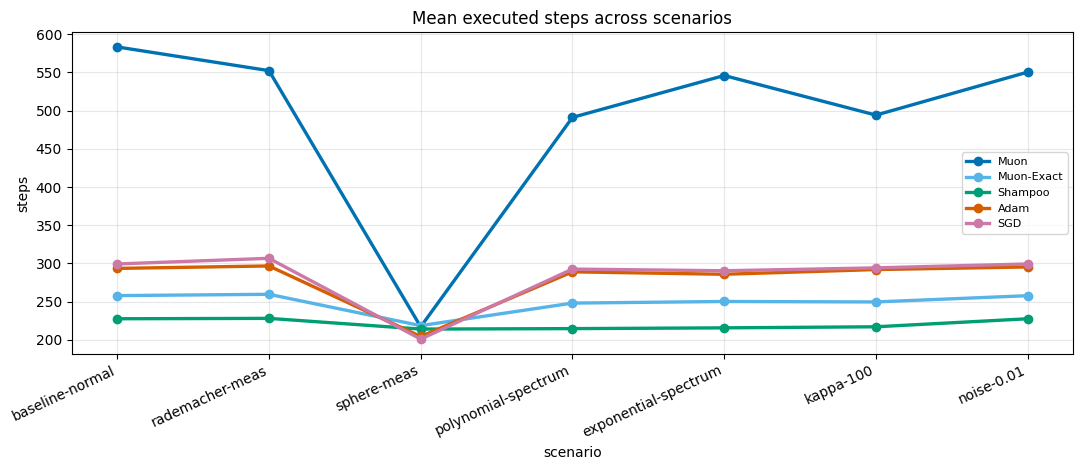

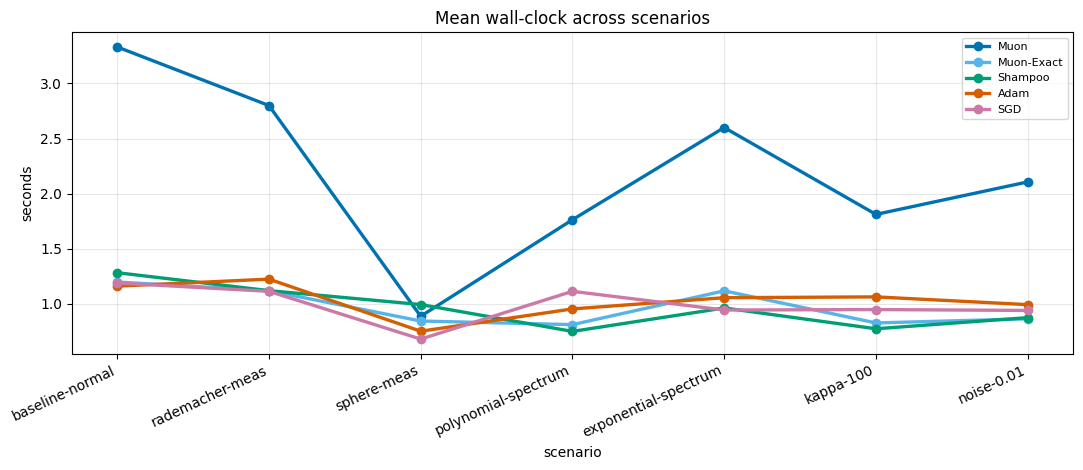

In [ ]:
fig, ax = plotting.plot_scenario_metric(run_summary, "actual_steps", "Mean executed steps across scenarios", "steps")
show_figure(fig)

fig, ax = plotting.plot_scenario_metric(run_summary, "time_s", "Mean wall-clock across scenarios", "seconds")
show_figure(fig)


## Scenario Minimum Loss

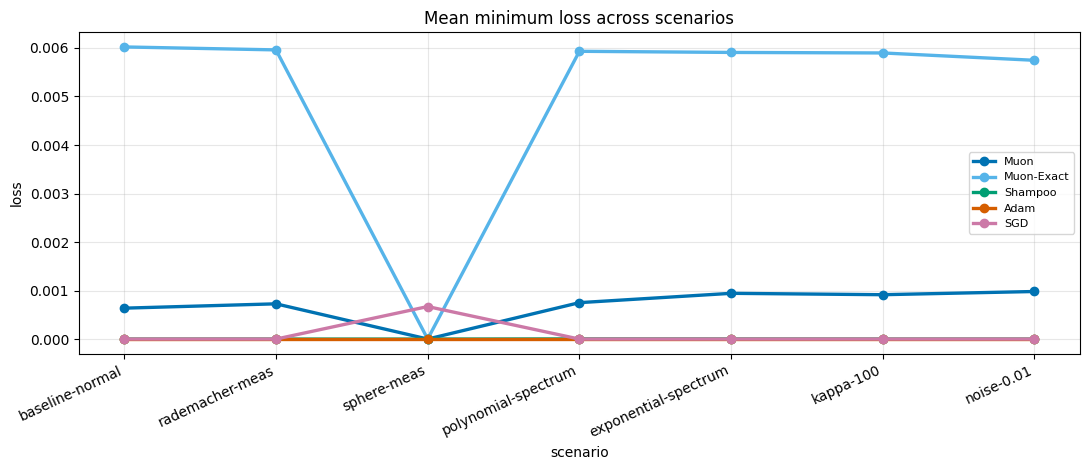

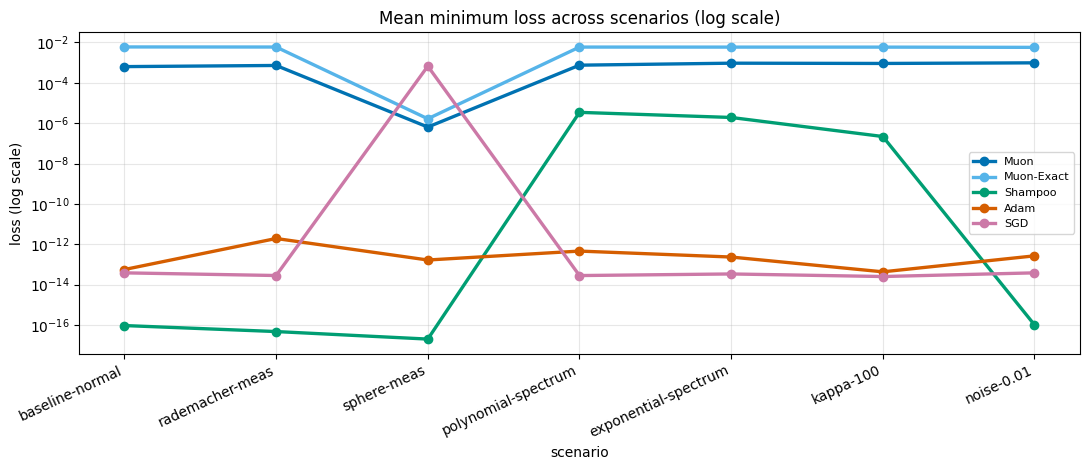

In [ ]:
fig, ax = plotting.plot_scenario_metric(run_summary, "min_loss", "Mean minimum loss across scenarios", "loss")
show_figure(fig)

fig, ax = plotting.plot_scenario_metric(run_summary, "min_loss", "Mean minimum loss across scenarios", "loss", log_y=True)
show_figure(fig)


## Scenario Final Loss

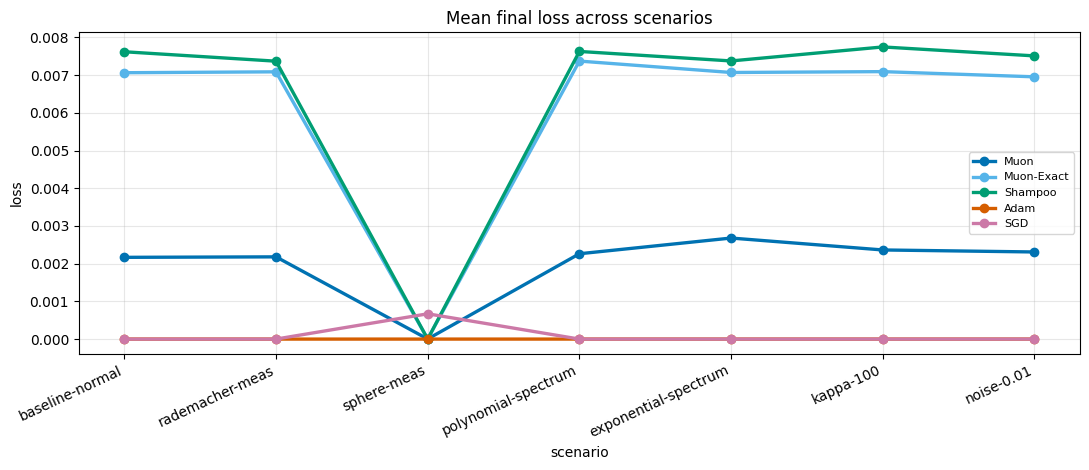

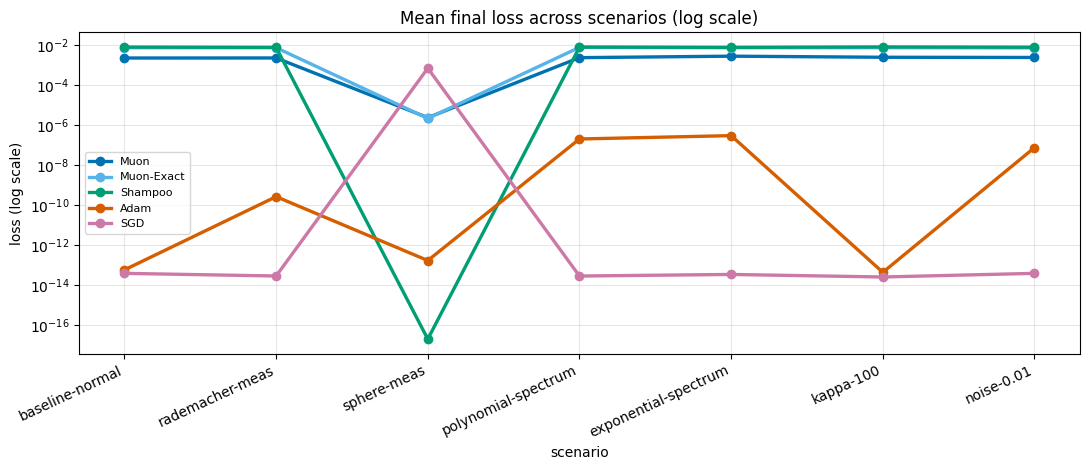

In [ ]:
fig, ax = plotting.plot_scenario_metric(run_summary, "final_loss", "Mean final loss across scenarios", "loss")
show_figure(fig)

fig, ax = plotting.plot_scenario_metric(run_summary, "final_loss", "Mean final loss across scenarios", "loss", log_y=True)
show_figure(fig)


## Per-Scenario Metric Overview

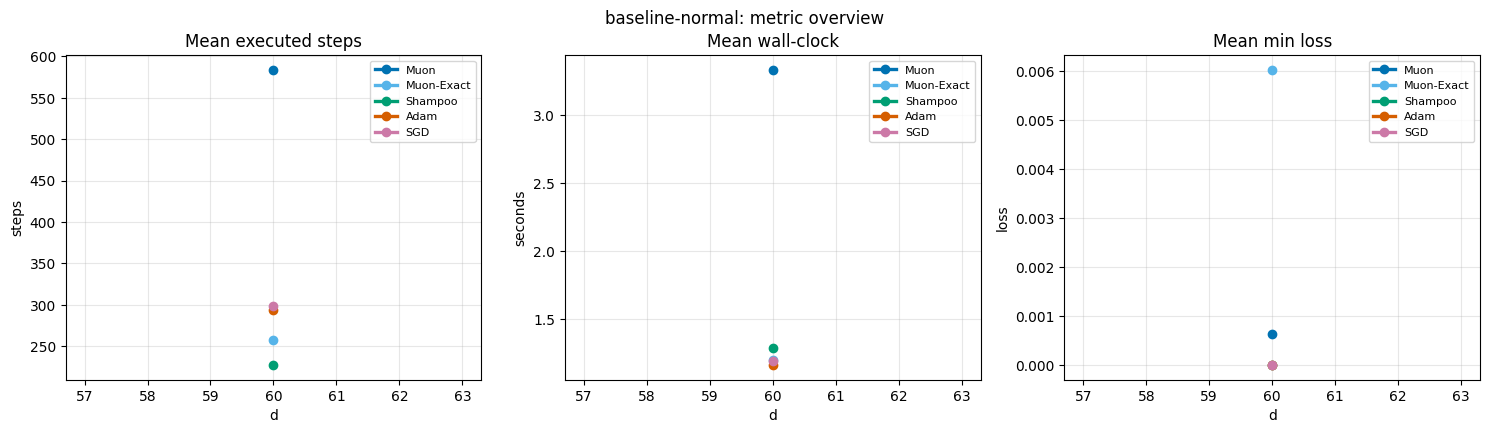

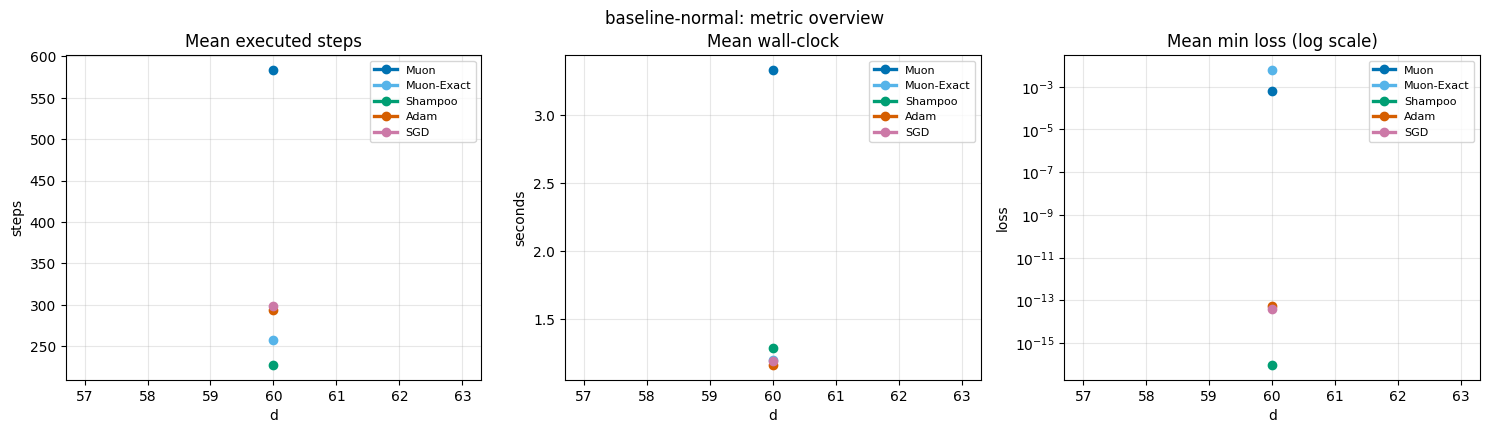

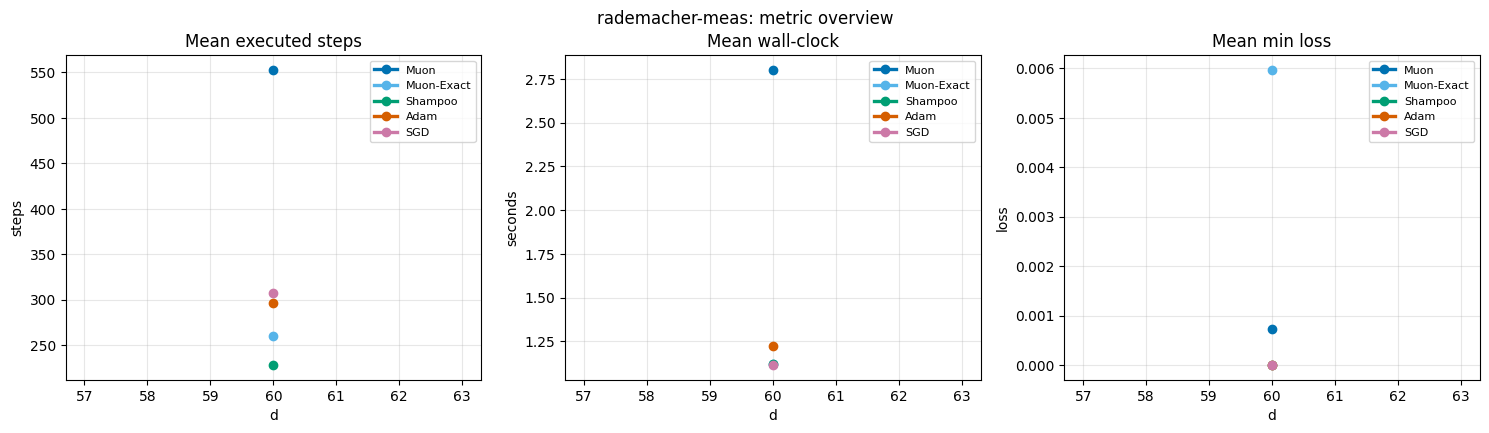

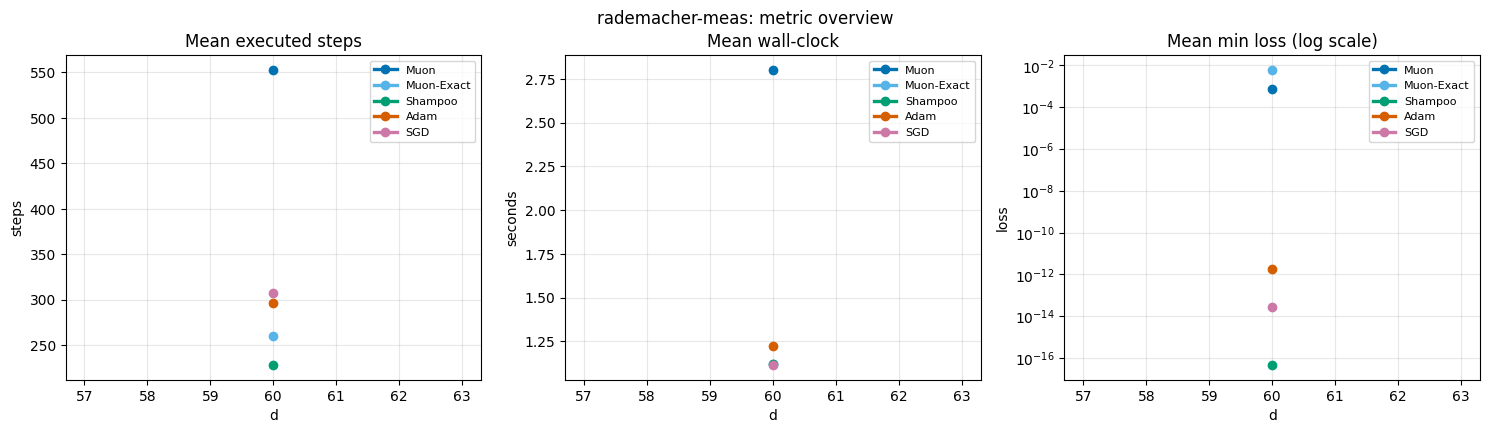

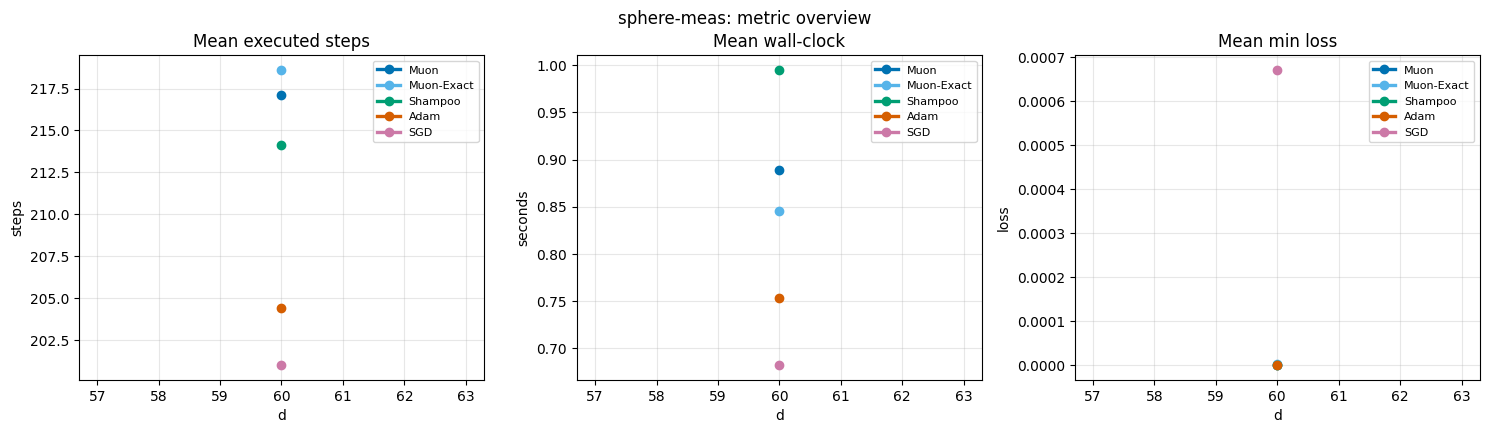

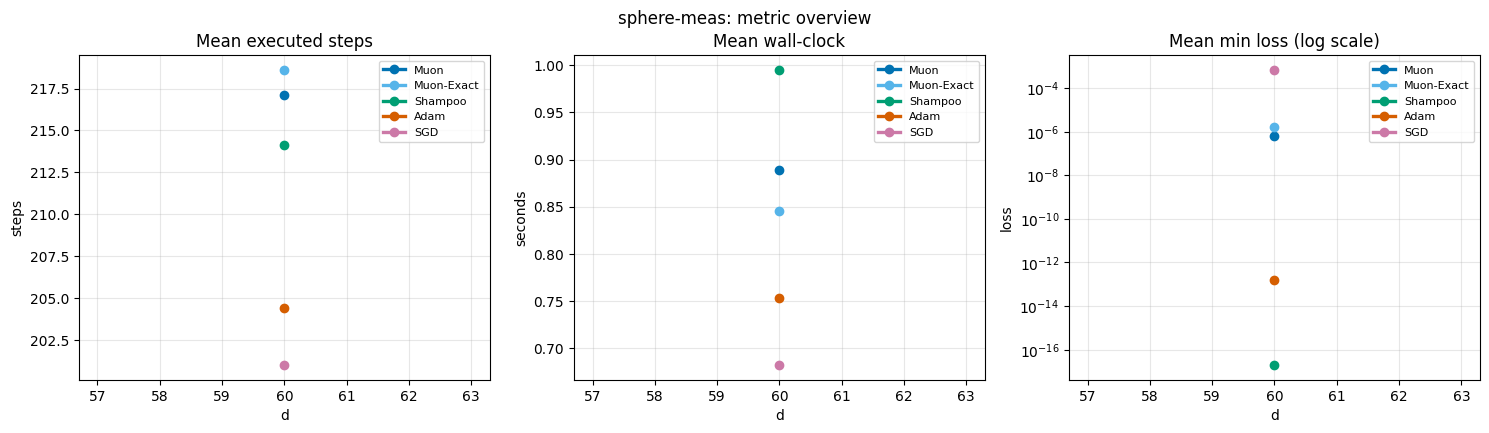

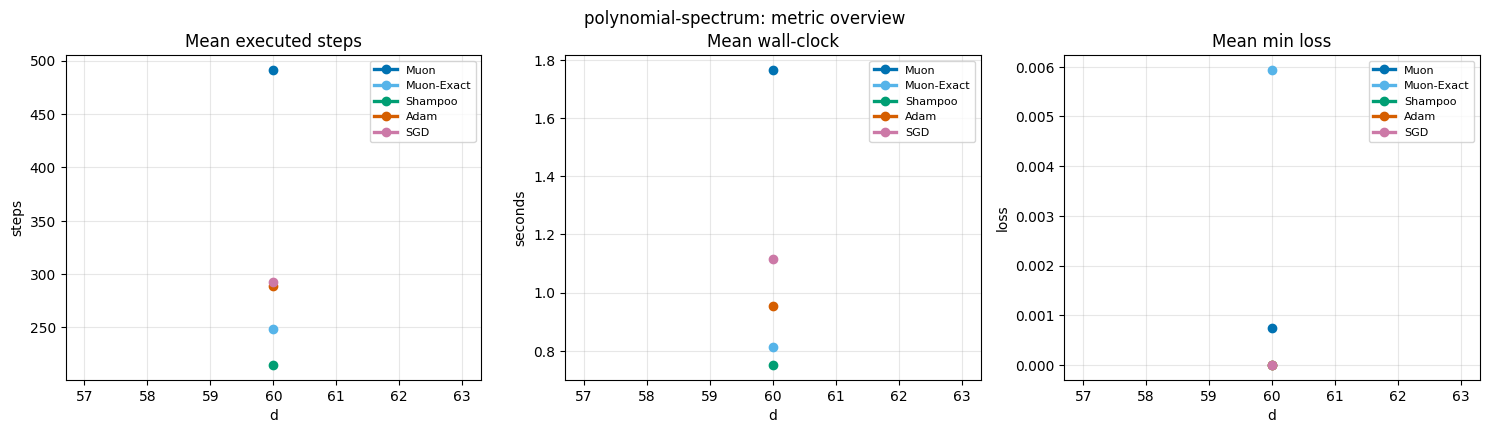

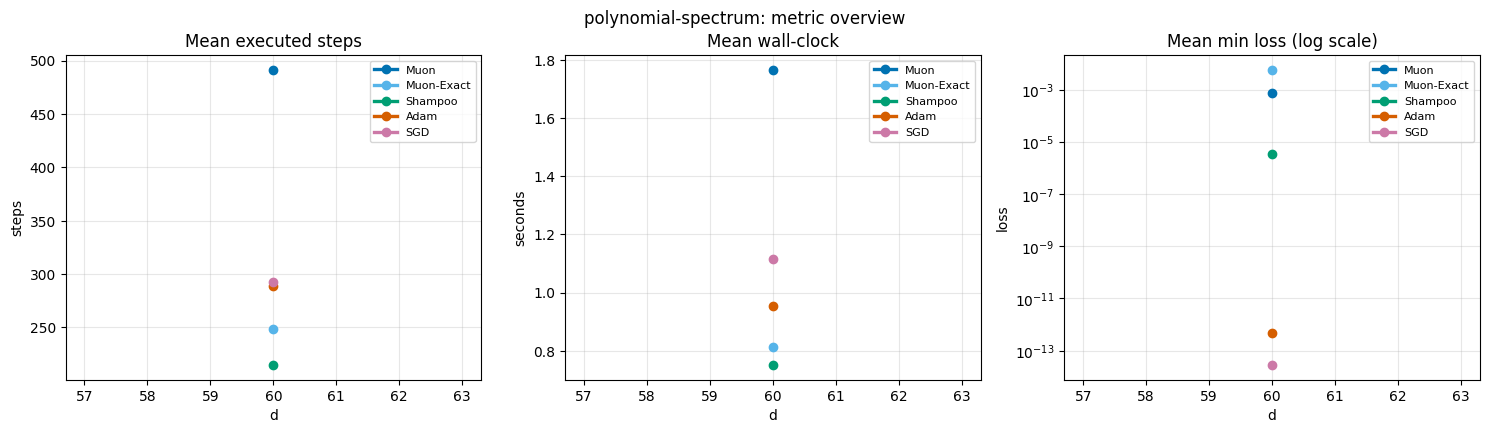

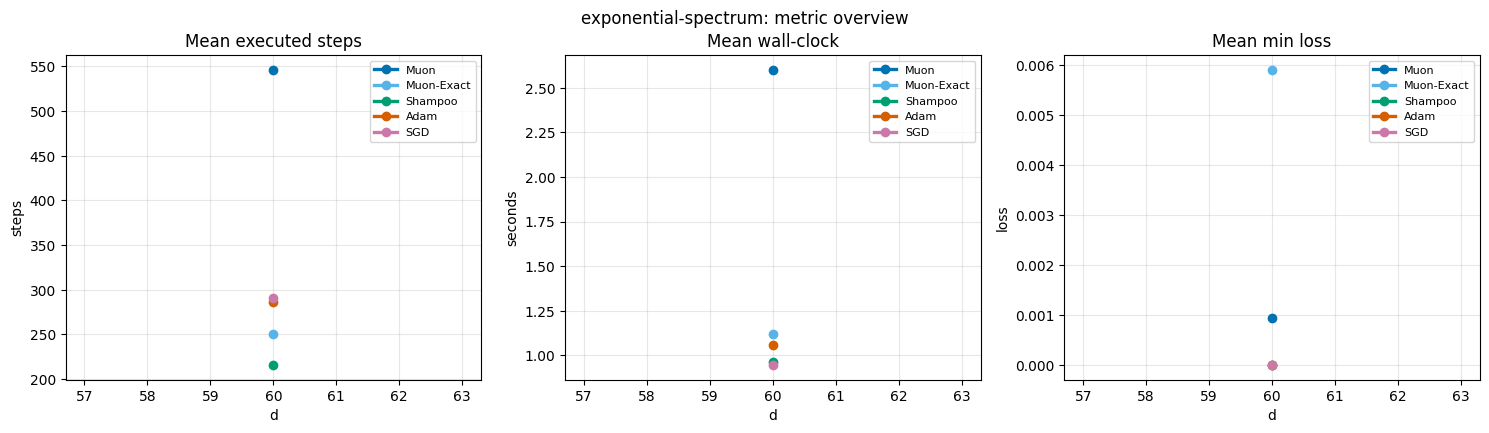

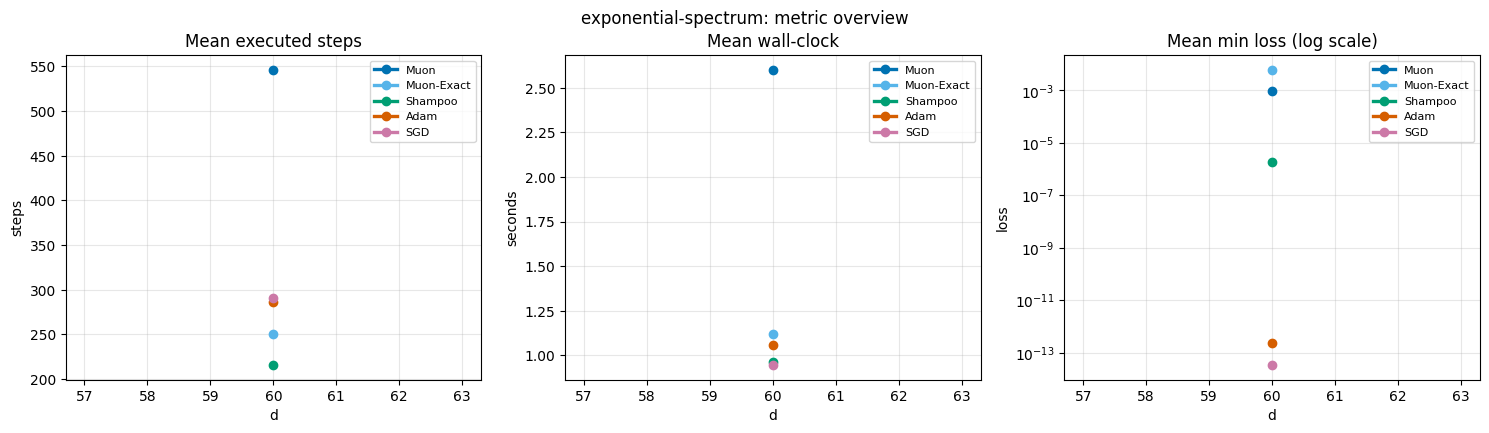

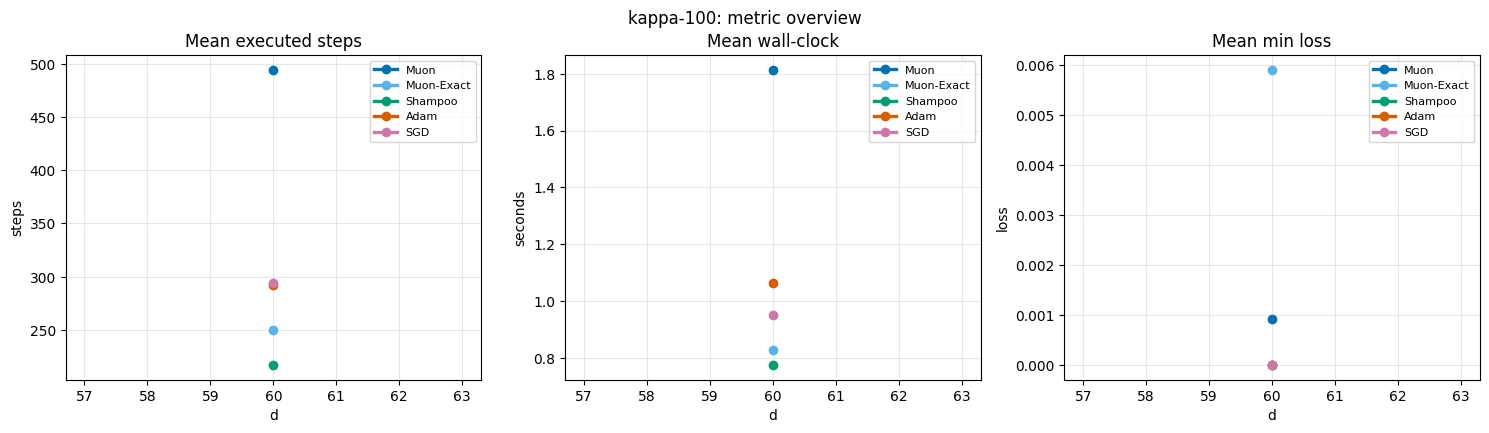

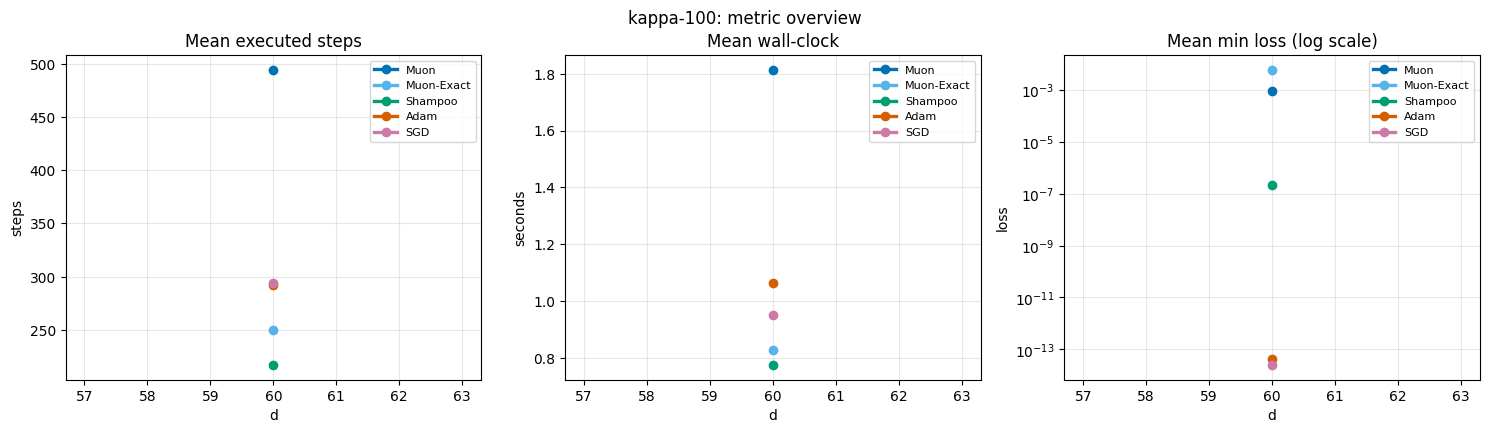

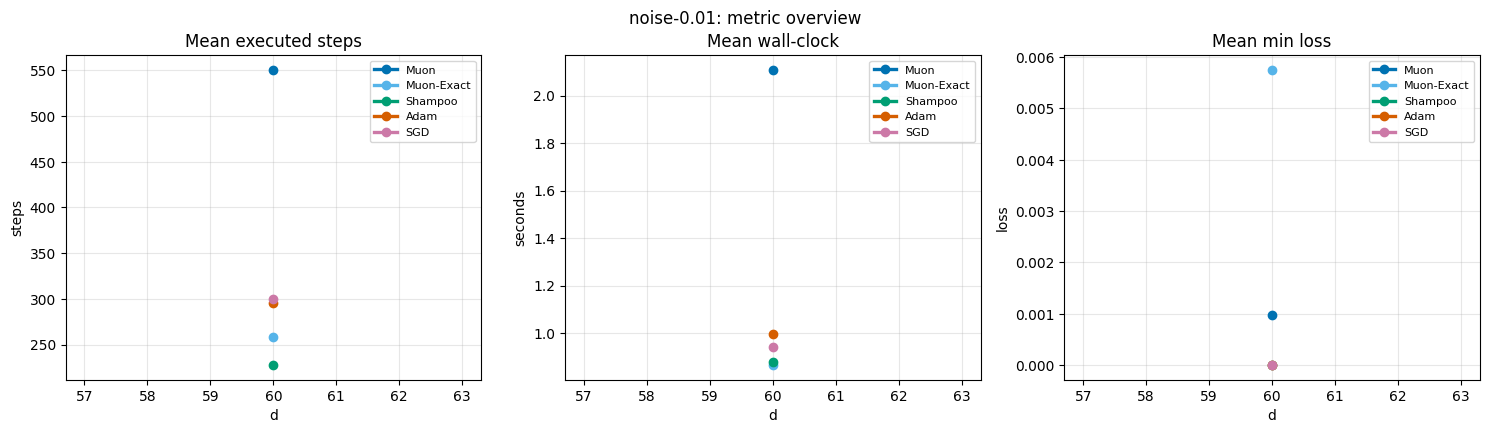

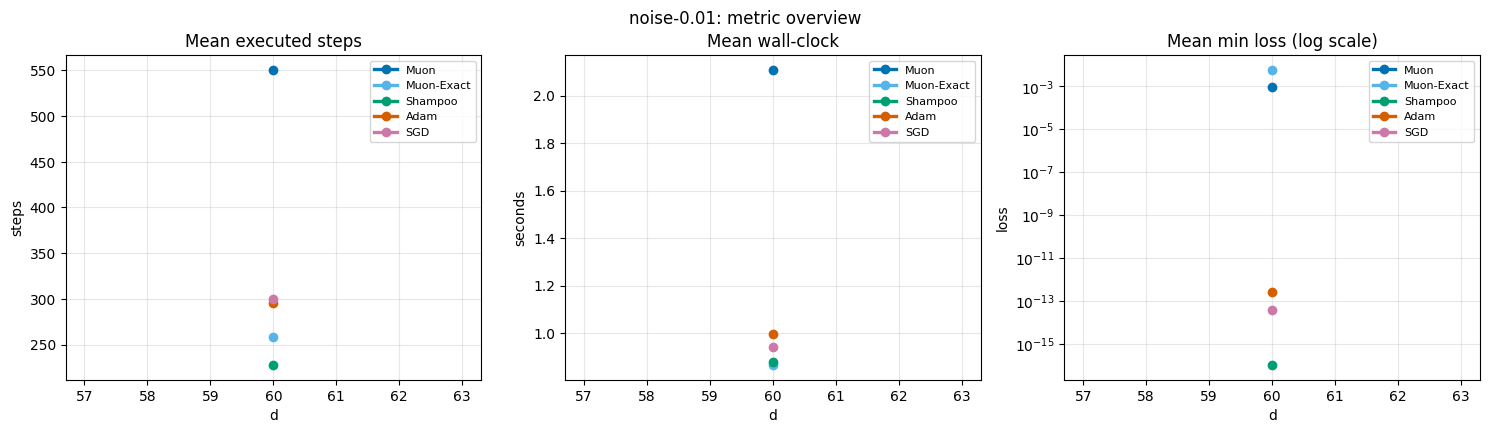

In [ ]:
for scenario in SCENARIO_ORDER:
    sub_summary = run_summary[run_summary["scenario"] == scenario]
    for loss_log_y in (False, True):
        fig, axes = plotting.plot_metric_overview(sub_summary, loss_log_y=loss_log_y)
        fig.suptitle(f"{scenario}: metric overview", y=1.02)
        show_figure(fig)


## Per-Scenario Algorithm Trajectories

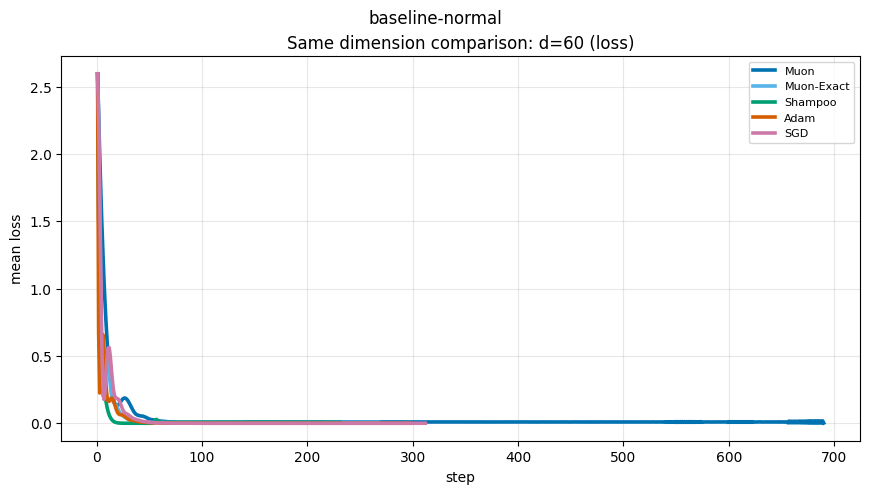

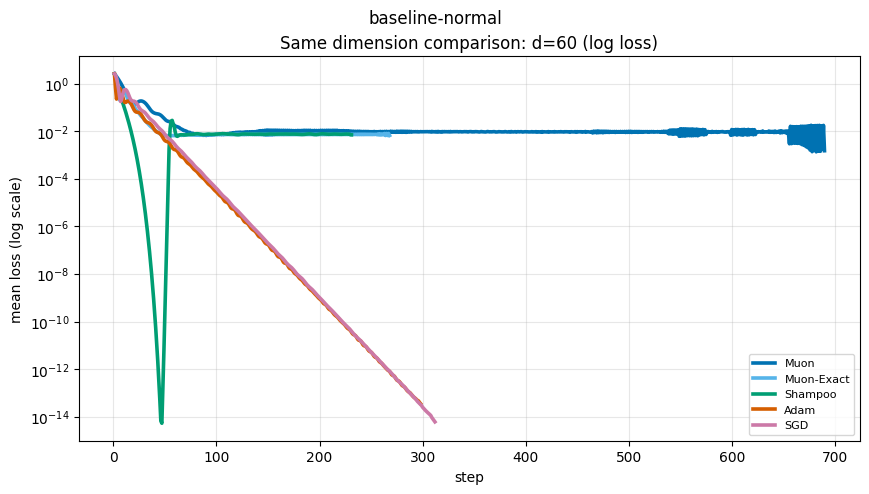

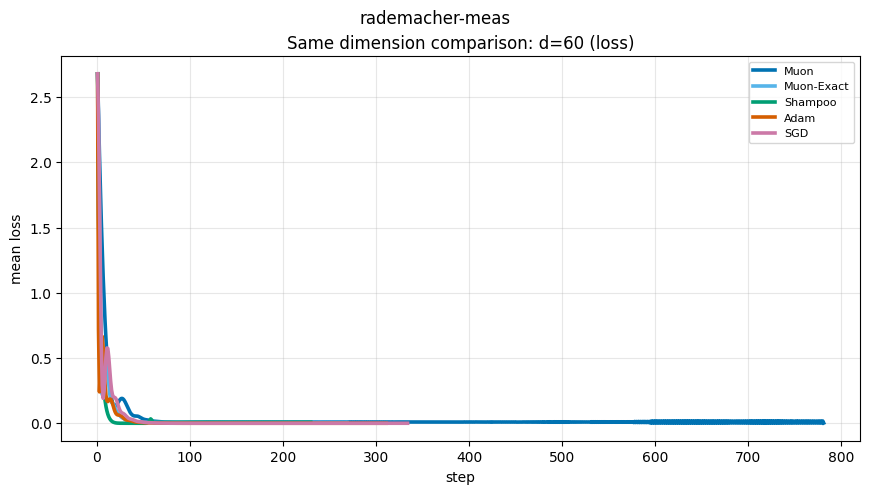

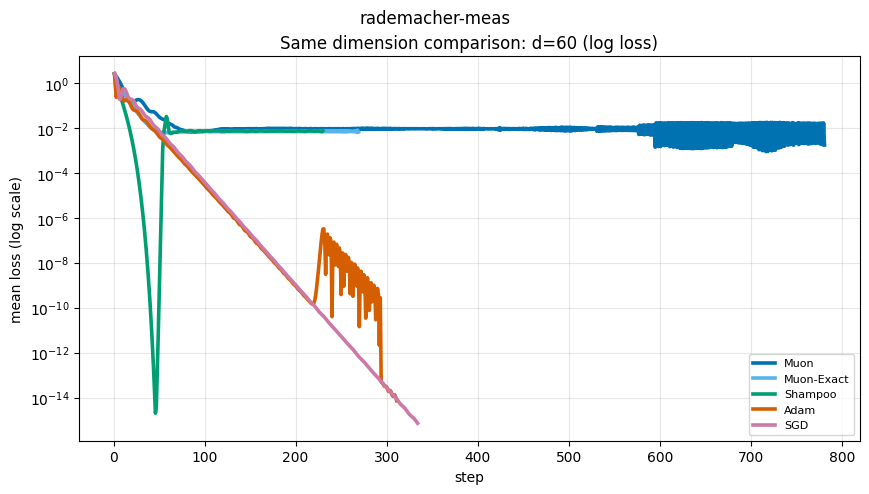

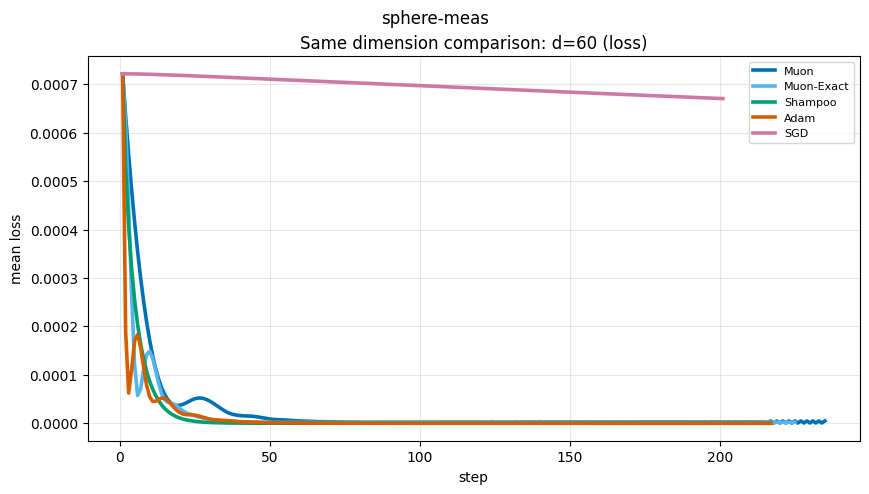

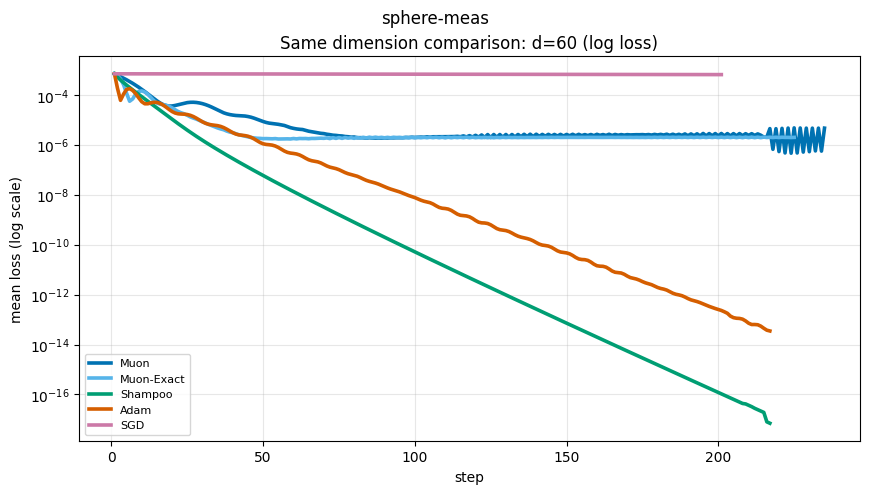

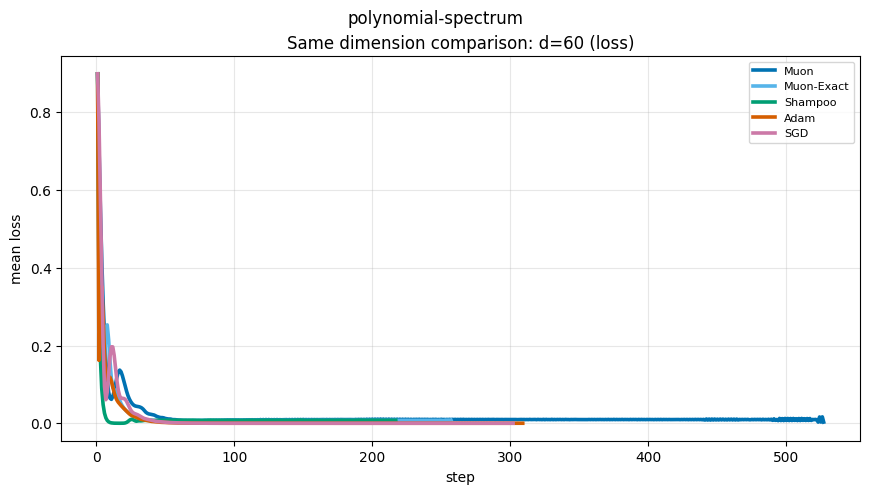

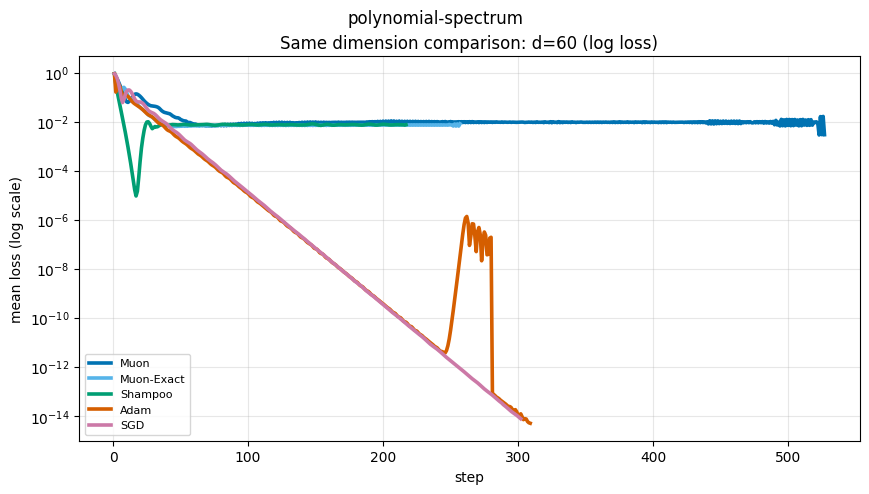

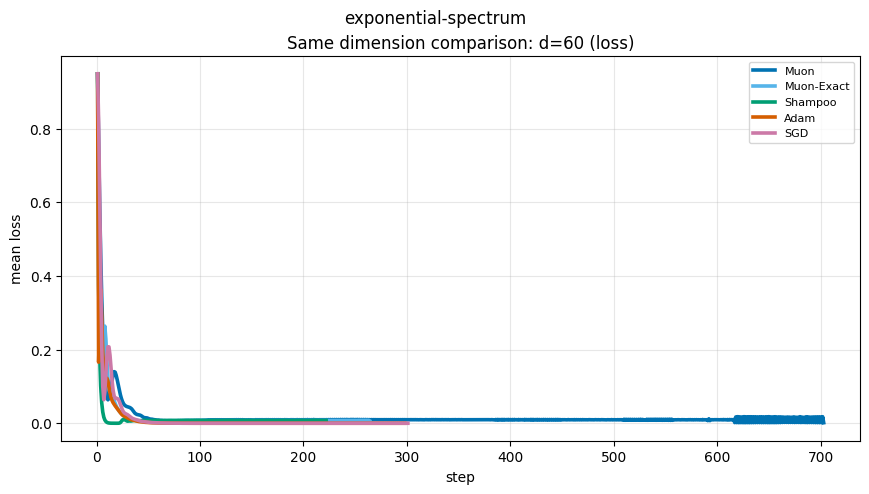

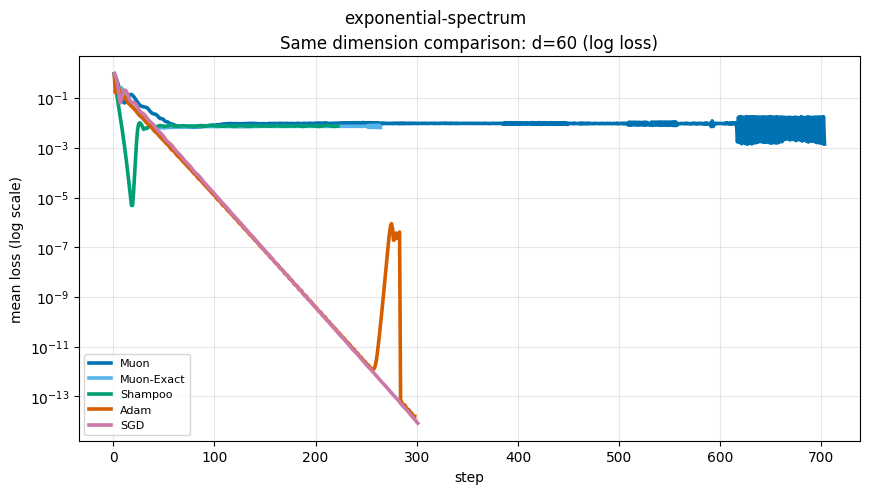

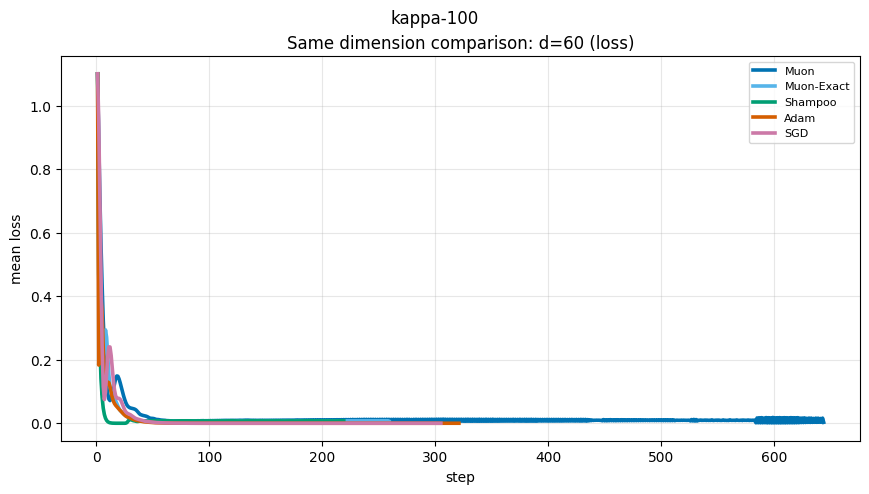

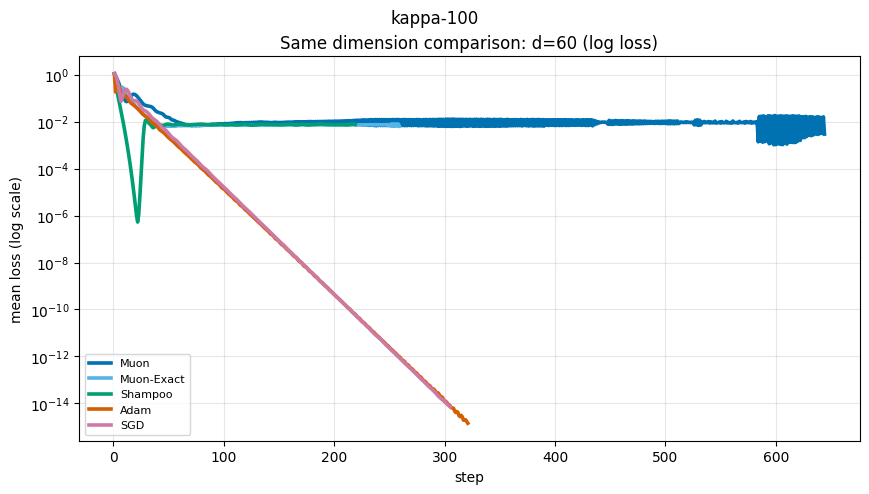

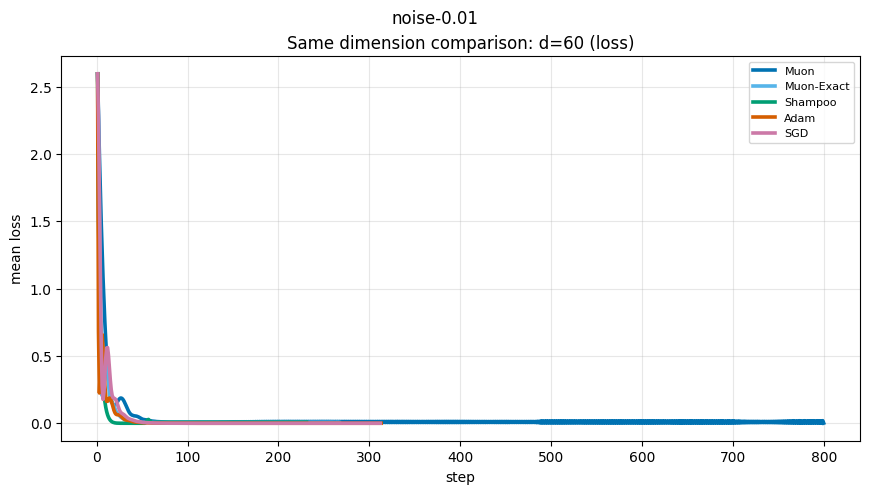

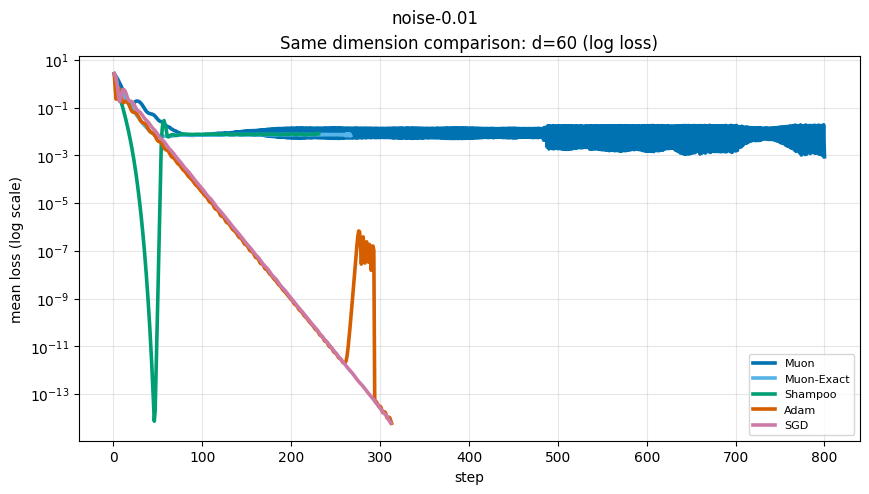

In [ ]:
for scenario in SCENARIO_ORDER:
    sub_runs = runs[runs["scenario"] == scenario]
    scenario_trajectories = trajectories_from(sub_runs)
    for log_y in (False, True):
        fig, ax = plotting.plot_algorithms_for_dimension(scenario_trajectories, BASE_SPEC["d"], log_y=log_y)
        fig.suptitle(scenario, y=1.02)
        show_figure(fig)


## Per-Scenario Seed Variability

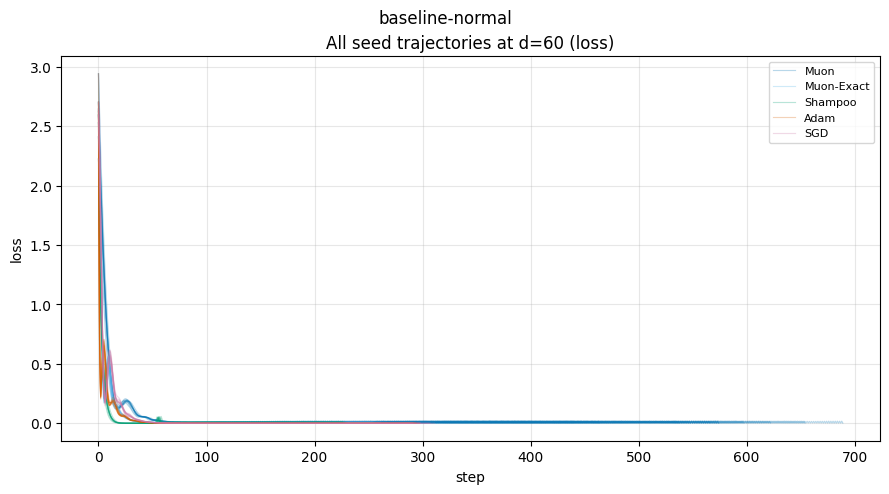

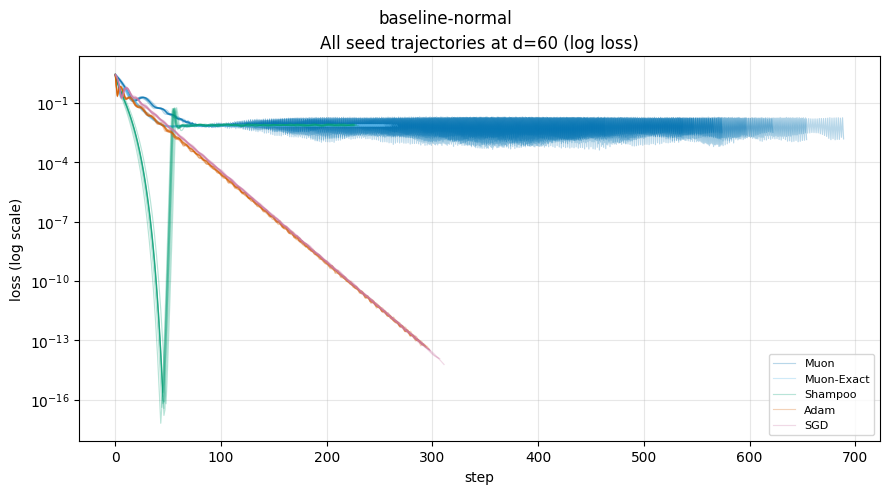

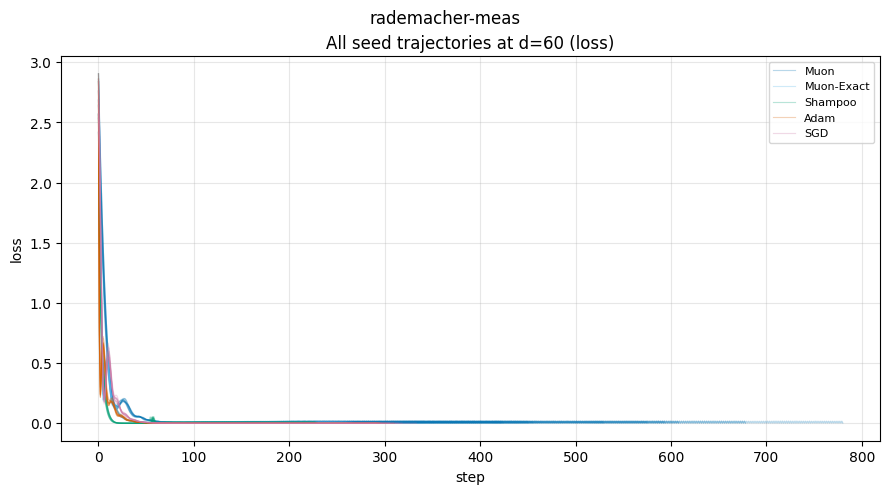

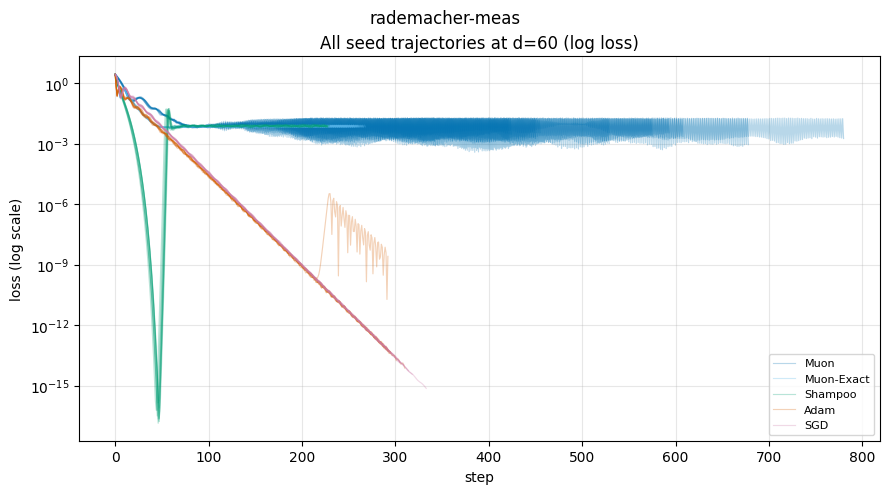

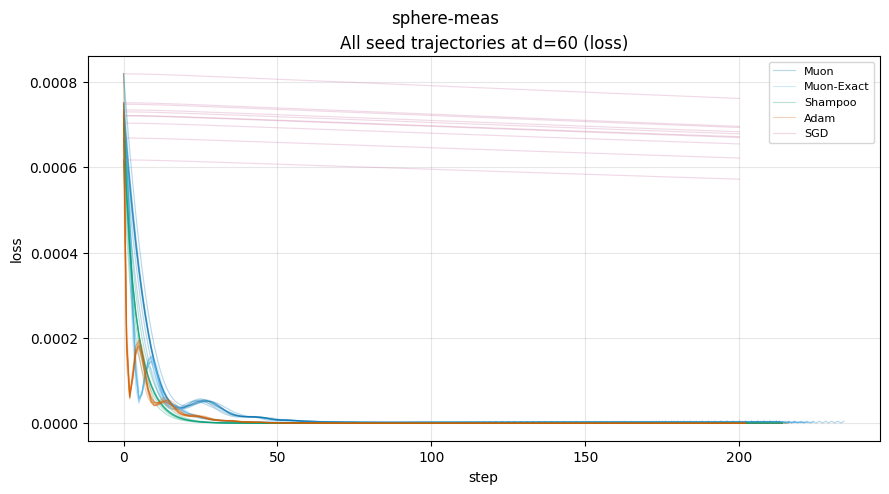

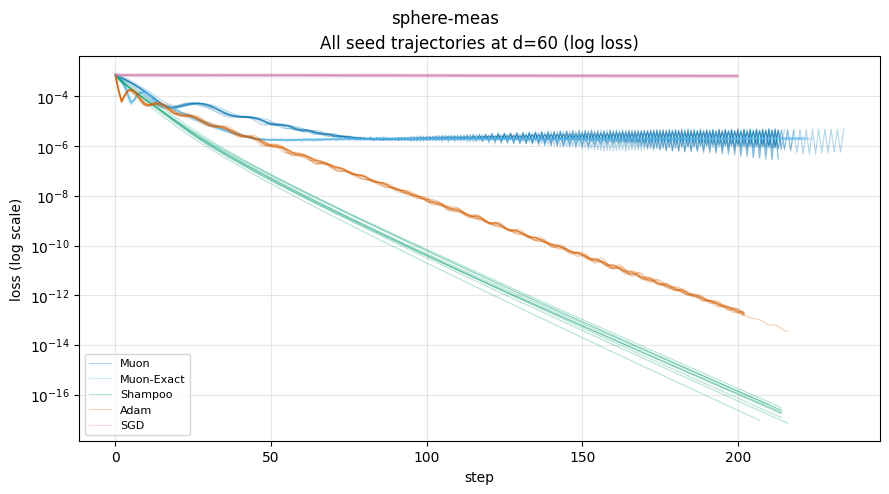

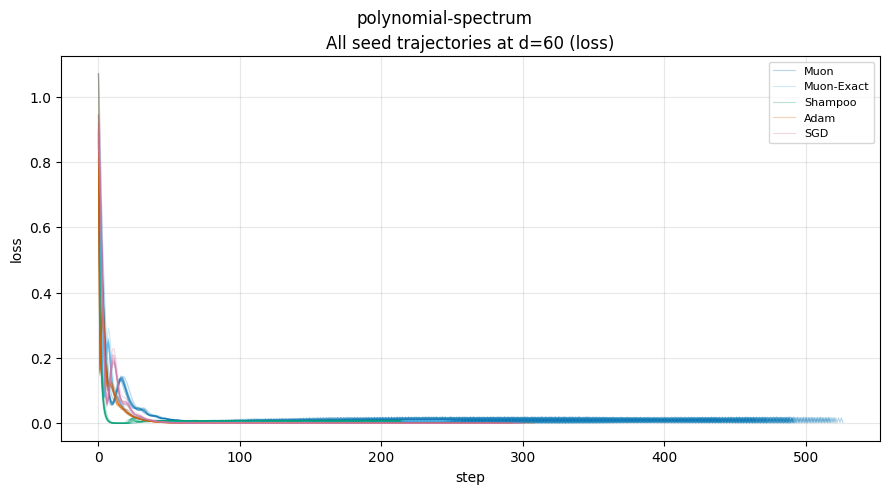

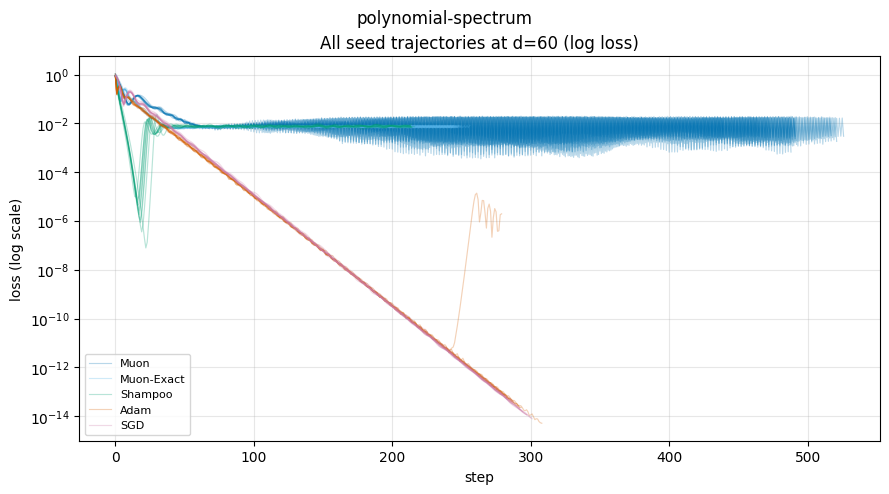

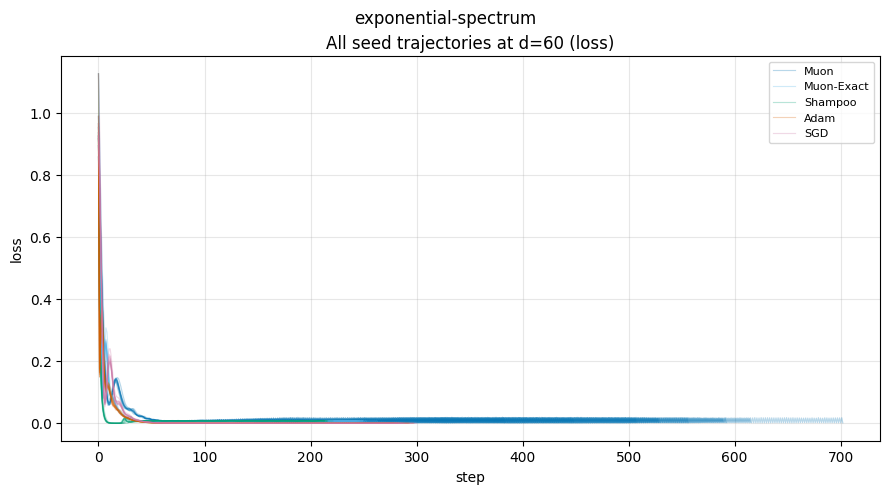

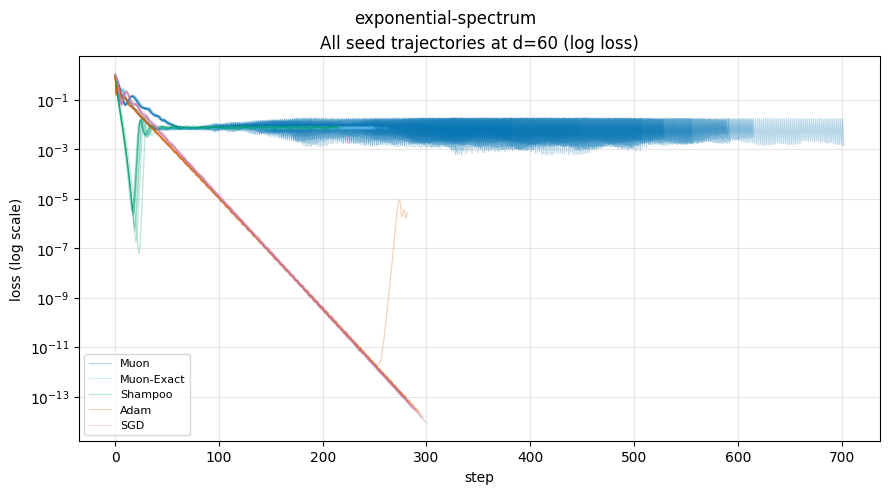

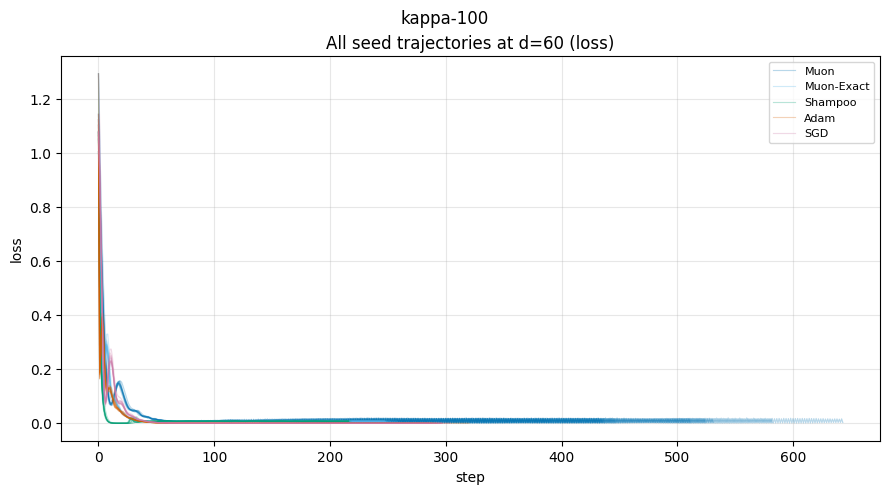

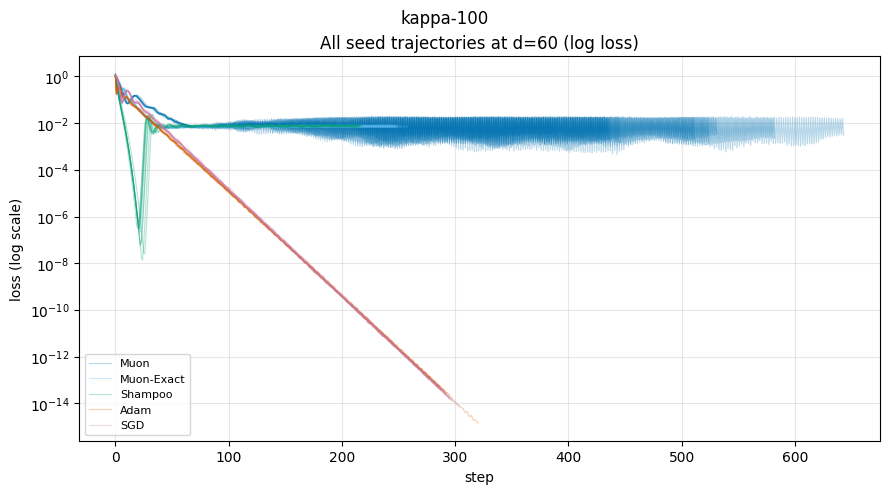

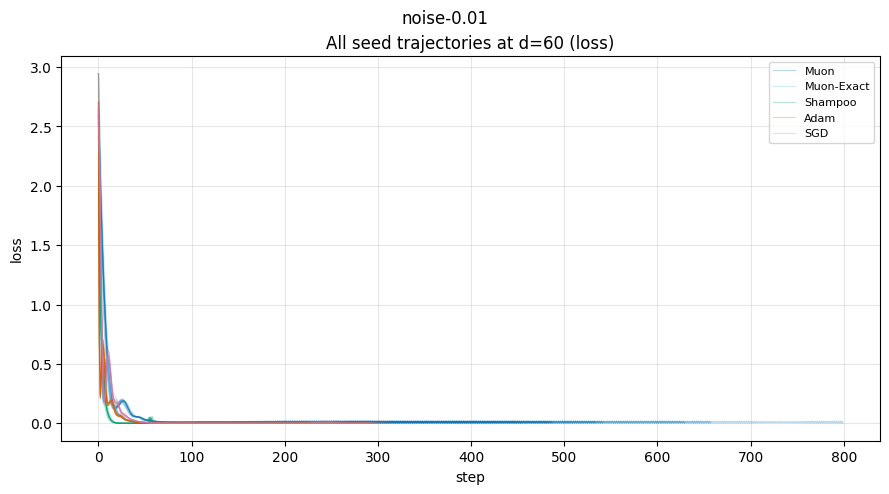

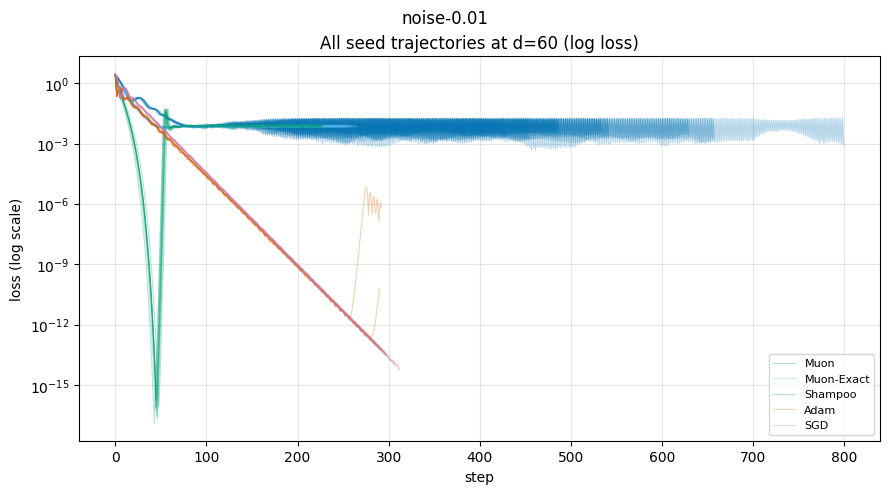

In [ ]:
for scenario in SCENARIO_ORDER:
    sub_runs = runs[runs["scenario"] == scenario]
    scenario_trajectories = trajectories_from(sub_runs)
    for log_y in (False, True):
        fig, ax = plotting.plot_seed_variability_for_dimension(scenario_trajectories, BASE_SPEC["d"], log_y=log_y)
        fig.suptitle(scenario, y=1.02)
        show_figure(fig)


## Conclusion

In [ ]:
def conclusion_markdown(run_summary):
    max_steps = int(run_summary["iters"].sum())
    actual_steps = int(run_summary["actual_steps"].sum())
    stopped = int(run_summary["stopped_early"].sum())
    lines = [
        "### Result Summary",
        "",
        f"- Scenarios: `{len(SCENARIO_ORDER)}`",
        f"- Runs: `{len(run_summary)}`",
        f"- Methods: `{', '.join(sorted(run_summary['algo'].unique()))}`",
        f"- Max iterations per run: `{int(run_summary['iters'].iloc[0])}`",
        f"- Max optimizer-step budget: `{max_steps}`",
        f"- Executed optimizer steps: `{actual_steps}` (`{max_steps - actual_steps}` skipped by early stopping)",
        f"- Early-stopped runs: `{stopped}/{len(run_summary)}`",
        "",
    ]
    for scenario in SCENARIO_ORDER:
        sub = scenario_summary[scenario_summary["scenario"] == scenario]
        fewest_steps = sub.loc[sub["actual_steps_mean"].idxmin()]
        best_time = sub.loc[sub["time_s_mean"].idxmin()]
        best_loss = sub.loc[sub["min_loss_mean"].idxmin()]
        lines.append(
            f"- {scenario}: fewest executed steps is `{fewest_steps.algo}` at `{fewest_steps.actual_steps_mean:.1f}` steps; "
            f"fastest wall-clock is `{best_time.algo}` at `{best_time.time_s_mean:.3f}s`; "
            f"lowest min_loss is `{best_loss.algo}` at `{best_loss.min_loss_mean:.3e}`."
        )
    lines.append("")
    lines.append("This ablation identifies which assumptions in E01 make the problem easy or hard: measurement distribution, spectrum shape, conditioning, and observation noise.")
    lines.append("Use this notebook to explain long runtimes when a scenario both converges slowly and uses expensive optimizer updates.")
    return "\n".join(lines)


IPython.display.display(IPython.display.Markdown(conclusion_markdown(run_summary)))


### Result Summary

- Scenarios: `7`
- Runs: `350`
- Methods: `Adam, Muon, Muon-Exact, SGD, Shampoo`
- Max iterations per run: `2000`
- Max optimizer-step budget: `700000`
- Executed optimizer steps: `106612` (`593388` skipped by early stopping)
- Early-stopped runs: `350/350`

- baseline-normal: fewest executed steps is `Shampoo` at `227.6` steps; fastest wall-clock is `Adam` at `1.162s`; lowest min_loss is `Shampoo` at `9.259e-17`.
- rademacher-meas: fewest executed steps is `Shampoo` at `228.1` steps; fastest wall-clock is `SGD` at `1.115s`; lowest min_loss is `Shampoo` at `4.665e-17`.
- sphere-meas: fewest executed steps is `SGD` at `201.0` steps; fastest wall-clock is `SGD` at `0.682s`; lowest min_loss is `Shampoo` at `1.976e-17`.
- polynomial-spectrum: fewest executed steps is `Shampoo` at `214.7` steps; fastest wall-clock is `Shampoo` at `0.751s`; lowest min_loss is `SGD` at `2.789e-14`.
- exponential-spectrum: fewest executed steps is `Shampoo` at `215.7` steps; fastest wall-clock is `SGD` at `0.945s`; lowest min_loss is `SGD` at `3.348e-14`.
- kappa-100: fewest executed steps is `Shampoo` at `217.1` steps; fastest wall-clock is `Shampoo` at `0.775s`; lowest min_loss is `SGD` at `2.497e-14`.
- noise-0.01: fewest executed steps is `Shampoo` at `227.6` steps; fastest wall-clock is `Muon-Exact` at `0.866s`; lowest min_loss is `Shampoo` at `9.990e-17`.

This ablation identifies which assumptions in E01 make the problem easy or hard: measurement distribution, spectrum shape, conditioning, and observation noise.
Use this notebook to explain long runtimes when a scenario both converges slowly and uses expensive optimizer updates.